In [1]:
import numpy as np
import zipfile
import os
import shutil

In [5]:
PATH = 'data/dogs_vs_cats'

# os.makedirs(PATH, exist_ok=True)

# with zipfile.ZipFile('data/dogs-vs-cats.zip') as z:
#     z.extractall(PATH)

In [ ]:
# with zipfile.ZipFile(PATH+'/train.zip') as z:
#     z.extractall(PATH)
# with zipfile.ZipFile(PATH+'/test1.zip') as z:
#     z.extractall(PATH)

In [ ]:
# def extract_dog_cat_files(file_path: str):
#     dog_path = os.path.join(file_path, "dog")
#     cat_path = os.path.join(file_path, "cat")

#     os.makedirs(dog_path, exist_ok=True)
#     os.makedirs(cat_path, exist_ok=True)

#     for file in os.listdir(file_path):
#         src = os.path.join(file_path, file)

#         if not os.path.isfile(src):
#             continue
#         if file.startswith("dog"):
#             shutil.move(src, os.path.join(dog_path, file))
#         elif file.startswith("cat"):
#             shutil.move(src, os.path.join(cat_path, file))

In [ ]:
# extract_dog_cat_files(PATH+'/train')

In [8]:
DOG_PATH = 'data/dogs_vs_cats/train/dog'
CAT_PATH = 'data/dogs_vs_cats/train/cat'

In [9]:
from PIL import Image
import numpy as np
import os

img_path = os.path.join(DOG_PATH, "dog.1.jpg")

img = Image.open(img_path)
img_np = np.array(img)

print(img_np.shape)   # (H, W, 3)
print(img_np.dtype)   # uint8

(499, 327, 3)
uint8


In [10]:
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

In [11]:
def conv_rgb(img, kernel) -> np.ndarray:
    out = np.zeros_like(img, dtype=float)
    for c in range(3):
        out[:,:,c] = convolve2d(img[:,:,c], kernel, mode='same')
    return out

In [12]:
kernel = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
])

kernels = {
    "sobel_x": np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ]),

    "sobel_y": np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ]),

    "laplacian": np.array([
        [ 0, -1,  0],
        [-1,  4, -1],
        [ 0, -1,  0]
    ]),

    "gaussian_blur": np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ]) / 16,

    "sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]
    ])
}


In [13]:
def show_compare(img, kernel, name):
    out = conv_rgb(img, kernel)
    out = np.clip(out,0,255).astype(np.uint8)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(out)
    plt.title(name)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

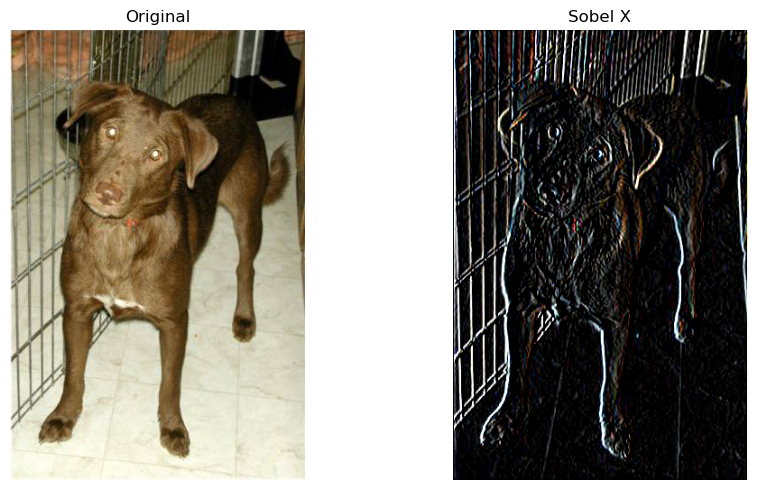

In [14]:
show_compare(img_np, kernels["sobel_x"], "Sobel X")

In [15]:
os.listdir(DOG_PATH).__len__(), os.listdir(CAT_PATH).__len__()

(12500, 12500)

In [16]:
img_path = os.path.join(CAT_PATH, "cat.1.jpg")

img = Image.open(img_path)
img_np = np.array(img)

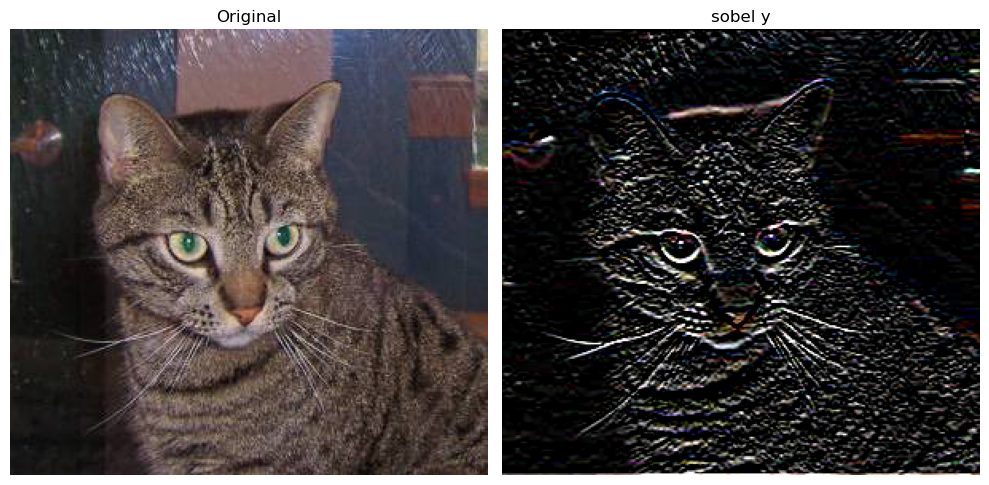

In [17]:
show_compare(img_np, kernels["sobel_y"], "sobel y")

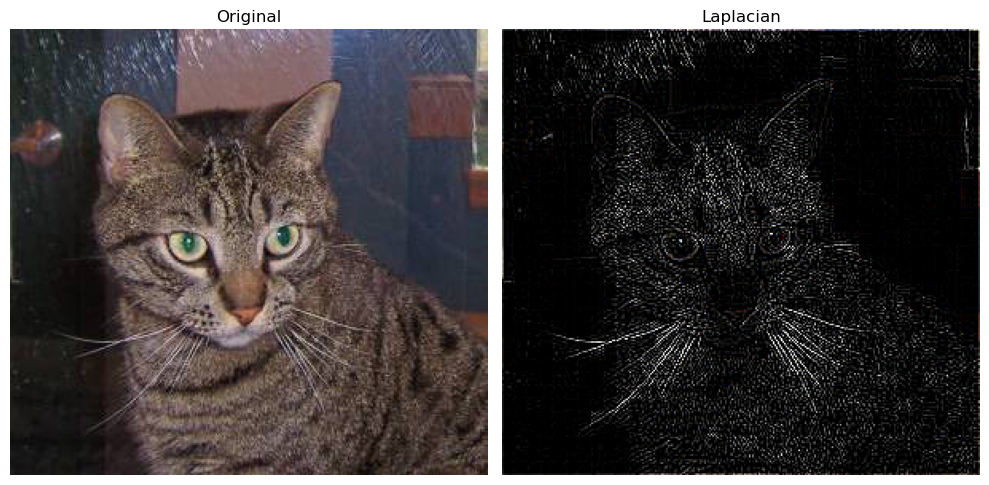

In [18]:
show_compare(img_np, kernels["laplacian"], "Laplacian")

In [19]:
laplacian_8 = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
])


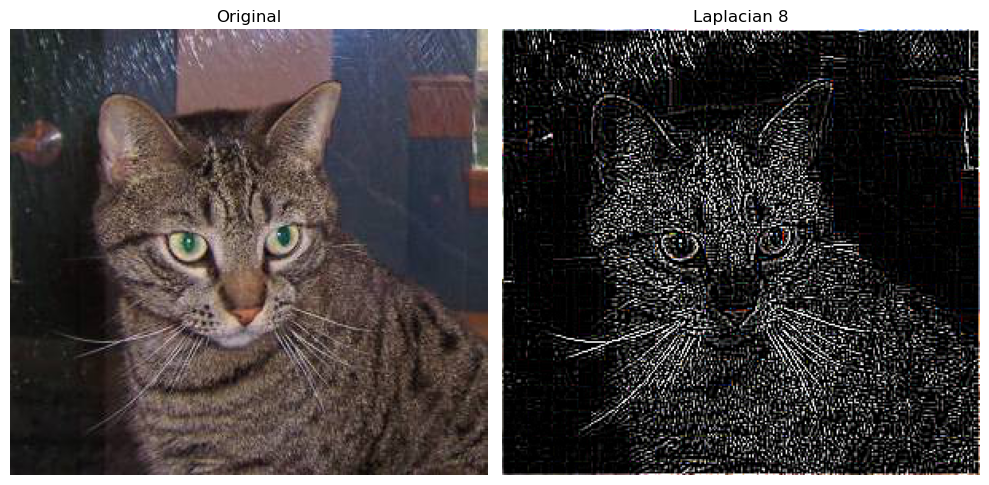

In [20]:
show_compare(img_np, laplacian_8, "Laplacian 8")

(-0.5, 299.5, 279.5, -0.5)

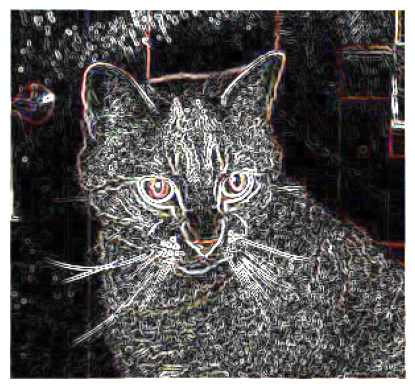

In [21]:
gx = conv_rgb(img_np, kernels["sobel_x"])
gy = conv_rgb(img_np, kernels["sobel_y"])

edge = np.sqrt(gx**2 + gy**2)
edge = np.clip(edge,0,255).astype(np.uint8)

plt.imshow(edge)
plt.axis("off")

In [22]:
import cv2
edges = cv2.Canny(img_np, 100, 200)


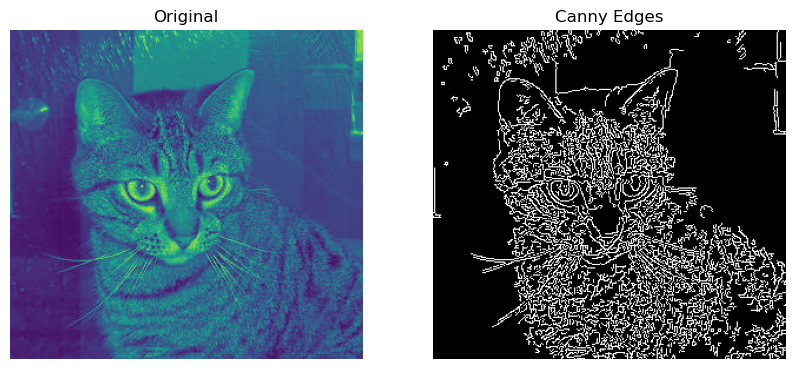

In [23]:
img = cv2.imread(os.path.join(CAT_PATH, 'cat.1.jpg'))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Canny edge detection
edges = cv2.Canny(gray, threshold1=100, threshold2=200)

# show side by side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.show()

In [24]:
import torch

In [25]:
def getDevice():
  if torch.cuda.is_available():
    return torch.device("cuda")
  elif torch.mps.is_available():
    return torch.device("mps")
  return torch.device("cpu")

device = getDevice()
device

device(type='cpu')